# Schritt 1: Die Maus sucht den Käse – Value Iteration

## Einordnung in den Kurs

Dieses Notebook implementiert das **Maus-und-Käse-Beispiel aus den Folien** Schritt für Schritt in Python.

| Foliensymbol | Bedeutung | Python-Name |
|---|---|---|
| $Z_t$ | Aktueller Zustand | `state` |
| $a_t$ | Ausgeführte Aktion | `action` |
| $b$ | Sofortige Belohnung | `reward` |
| $\gamma$ | Diskontierungsfaktor | `GAMMA` |
| $Q_{max}(Z_{t+1})$ | Bester Folgezustand-Q-Wert | `np.max(Q[next_state])` |

Die Update-Formel aus den Folien:

$$Q_{neu}(Z_t, a_t) = b + \gamma \cdot Q_{max}(Z_{t+1})$$

## Lernziele

Nach diesem Notebook sollten Sie:
- die Q-Update-Formel der Folien in Python-Code wiederfinden können
- erklären können, was eine Q-Tabelle ist und wie sie aufgebaut wird
- den Diskontierungsfaktor $\gamma$ in seiner Wirkung interpretieren können
- den Unterschied zwischen Value Iteration und Q-Learning benennen können

## Leitfragen

- Was steht in der Q-Tabelle – und was bedeutet ein hoher Q-Wert?
- Warum lernt Z2 erst in Iteration 2, obwohl die Belohnung schon in Iteration 1 vergeben wird?
- Was passiert mit den Q-Werten, wenn $\gamma = 0$ oder $\gamma = 1$?
- Warum kann Value Iteration nicht für CartPole (K13_03) verwendet werden?

# Schritt 2: Imports und Parameter

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

# ── Parameter (exakt wie auf den Folien) ──────────────────────────────────
GRID_SIZE    = 3          # 3x3 Gitter
NUM_STATES   = 9          # Z1 bis Z9
NUM_ACTIONS  = 4          # oben, unten, links, rechts

START_STATE  = 0          # Z1 (Index 0)
GOAL_STATE   = 5          # Z6 (Index 5) -- Kaese

GAMMA        = 0.9        # Diskontierungsfaktor (wie auf Folie)
REWARD_GOAL  = 100        # Belohnung im Zielzustand (wie auf Folie)

# Aktionen: (delta_zeile, delta_spalte)
ACTIONS = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}
ACTION_NAMES = ['oben', 'unten', 'links', 'rechts']
ARROW_CHARS  = ['↑', '↓', '←', '→']

print("Parameter gesetzt (identisch mit den Folien):")
print(f"  Gitter:         {GRID_SIZE}x{GRID_SIZE} = {NUM_STATES} Zustaende (Z1-Z9)")
print(f"  Startzustand:   Z{START_STATE+1}  (Maus)")
print(f"  Zielzustand:    Z{GOAL_STATE+1}  (Kaese)")
print(f"  Gamma:          {GAMMA}")
print(f"  Belohnung Ziel: {REWARD_GOAL}")
print()
print("Q-Tabellen-Groesse (Vergleich):")
q_size = NUM_STATES * NUM_ACTIONS
print(f"  Q-Tabelle:  {NUM_STATES} x {NUM_ACTIONS} = {q_size} Eintraege  (tabular, skaliert nicht)")
print(f"  DQN K13_03: 4 x 64 + 64 + 64 x 64 + 64 + 64 x 2 + 2 = 4.610 Parameter  (skaliert!)")
print(f"  -> Das ist die Motivation fuer Deep Q-Networks in K13_03")

Parameter gesetzt (identisch mit den Folien):
  Gitter:         3x3 = 9 Zustaende (Z1-Z9)
  Startzustand:   Z1  (Maus)
  Zielzustand:    Z6  (Kaese)
  Gamma:          0.9
  Belohnung Ziel: 100

Q-Tabellen-Groesse (Vergleich):
  Q-Tabelle:  9 x 4 = 36 Eintraege  (tabular, skaliert nicht)
  DQN K13_03: 4 x 64 + 64 + 64 x 64 + 64 + 64 x 2 + 2 = 4.610 Parameter  (skaliert!)
  -> Das ist die Motivation fuer Deep Q-Networks in K13_03


# Schritt 3: Das Gitter visualisieren – VOR dem Algorithmus

## Das Szenario

Bevor wir rechnen: Was sehen wir eigentlich?

- 3×3-Gitter mit 9 Feldern (Zuständen)
- Maus startet in Z1 (oben links)
- Käse liegt in Z6 (Mitte rechts)
- Von jedem Feld sind nur gültige Bewegungen erlaubt (keine Gitterwände durchqueren)

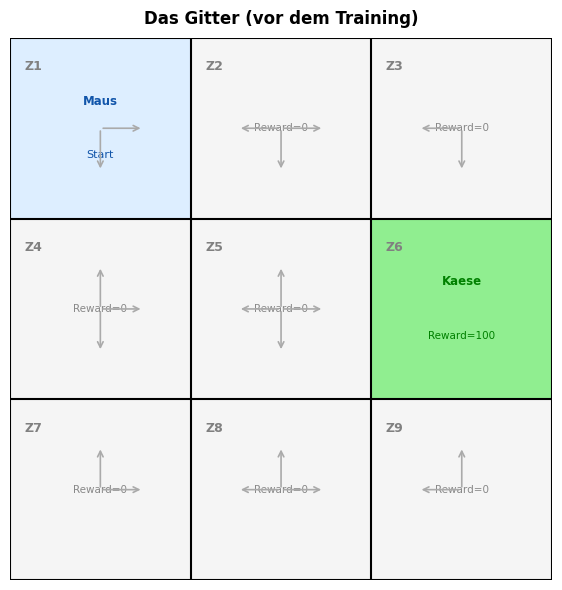

Jeder Zustand hat 2-4 moeglich Aktionen (Randfelder haben weniger).
In Z6 (Ziel) endet die Episode – daher braucht Z6 keinen Q-Wert.


In [ ]:
def draw_grid_setup(ax, title="Das Gitter (vor dem Training)"):
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

    # Gitterlinien
    for i in range(GRID_SIZE + 1):
        ax.plot([0, GRID_SIZE], [i, i], 'k-', lw=1.5)
        ax.plot([i, i], [0, GRID_SIZE], 'k-', lw=1.5)

    arrow_map = {0: (0, 0.28), 1: (0, -0.28), 2: (-0.28, 0), 3: (0.28, 0)}

    for s in range(NUM_STATES):
        r, c  = divmod(s, GRID_SIZE)
        px    = c + 0.5
        py    = GRID_SIZE - r - 0.5

        # Hintergrundfarbe
        if s == GOAL_STATE:
            bg = 'lightgreen'
        elif s == START_STATE:
            bg = '#DDEEFF'
        else:
            bg = '#F5F5F5'
        ax.add_patch(plt.Rectangle((c, GRID_SIZE-r-1), 1, 1,
                                    color=bg, zorder=0, linewidth=0))

        # Zustandsname
        ax.text(c+0.08, GRID_SIZE-r-0.18, f'Z{s+1}',
                fontsize=9, color='gray', fontweight='bold')

        # Maus und Kaese
        if s == START_STATE:
            ax.text(px, py+0.15, 'Maus', fontsize=8.5,
                    ha='center', va='center', color='#1155AA', fontweight='bold')
            ax.text(px, py-0.15, 'Start', fontsize=8,
                    ha='center', va='center', color='#1155AA')
        elif s == GOAL_STATE:
            ax.text(px, py+0.15, 'Kaese', fontsize=8.5,
                    ha='center', va='center', color='green', fontweight='bold')
            ax.text(px, py-0.15, 'Reward=100', fontsize=7.5,
                    ha='center', va='center', color='green')
        else:
            ax.text(px, py, f'Reward=0', fontsize=7.5,
                    ha='center', va='center', color='#888888')

        # Bewegungspfeile (nur gueltige)
        if s not in [GOAL_STATE]:
            r2, c2 = divmod(s, GRID_SIZE)
            for a, (dr, dc) in ACTIONS.items():
                nr, nc = r2+dr, c2+dc
                if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE:
                    dx, dy = arrow_map[a]
                    ax.annotate('', xy=(px+dx*0.85, py+dy*0.85),
                                xytext=(px, py),
                                arrowprops=dict(arrowstyle='->', color='#AAAAAA',
                                                lw=1.2))

fig, ax = plt.subplots(figsize=(6, 6))
draw_grid_setup(ax)
plt.tight_layout()
plt.show()

print("Jeder Zustand hat 2-4 moeglich Aktionen (Randfelder haben weniger).")
print("In Z6 (Ziel) endet die Episode – daher braucht Z6 keinen Q-Wert.")

# Schritt 4: Hilfsfunktionen

## Drei Bausteine, die wir immer wieder brauchen

In [ ]:
def state_to_pos(s):
    # Zustandsindex -> (Zeile, Spalte)
    # Z1=0 -> (0,0),  Z5=4 -> (1,1),  Z6=5 -> (1,2)
    return divmod(s, GRID_SIZE)

def pos_to_state(r, c):
    # (Zeile, Spalte) -> Zustandsindex
    return r * GRID_SIZE + c

def valid_actions(state):
    # Alle Aktionen, die nicht aus dem Gitter herausfuehren
    r, c  = state_to_pos(state)
    valid = []
    for a, (dr, dc) in ACTIONS.items():
        nr, nc = r + dr, c + dc
        if 0 <= nr < GRID_SIZE and 0 <= nc < GRID_SIZE:
            valid.append(a)
    return valid

def step(state, action):
    # Simuliert einen Schritt: gibt (folgezustand, b) zurueck
    # b = Belohnung (= REWARD_GOAL wenn Ziel erreicht, sonst 0)
    r, c       = state_to_pos(state)
    dr, dc     = ACTIONS[action]
    next_state = pos_to_state(r + dr, c + dc)
    b          = REWARD_GOAL if next_state == GOAL_STATE else 0   # b aus den Folien
    return next_state, b

# Kurztests
print("Konvertierung:")
for s in [0, 4, 5, 8]:
    r, c = state_to_pos(s)
    print(f"  Z{s+1} (Index {s}) -> Zeile {r}, Spalte {c}")

print()
print("Gueltige Aktionen pro Zustand:")
for s in [0, 1, 4, 5]:
    va = valid_actions(s)
    names = [ACTION_NAMES[a] for a in va]
    print(f"  Z{s+1}: {names}")

print()
print("Schritte testen:")
print(f"  Z3 (Index 2) + unten (1)  -> {step(2, 1)}  (Ziel! Reward=100)")
print(f"  Z1 (Index 0) + rechts (3) -> {step(0, 3)}  (Z2, Reward=0)")

Konvertierung:
  Z1 (Index 0) -> Zeile 0, Spalte 0
  Z5 (Index 4) -> Zeile 1, Spalte 1
  Z6 (Index 5) -> Zeile 1, Spalte 2
  Z9 (Index 8) -> Zeile 2, Spalte 2

Gueltige Aktionen pro Zustand:
  Z1: ['unten', 'rechts']
  Z2: ['unten', 'links', 'rechts']
  Z5: ['oben', 'unten', 'links', 'rechts']
  Z6: ['oben', 'unten', 'links']

Schritte testen:
  Z3 (Index 2) + unten (1)  -> (5, 100)  (Ziel! Reward=100)
  Z1 (Index 0) + rechts (3) -> (1, 0)  (Z2, Reward=0)


# Schritt 5: Value Iteration vs. Q-Learning – der entscheidende Unterschied

## Wie wird die Q-Tabelle aufgebaut?

Es gibt zwei grundlegend verschiedene Ansätze:

| Merkmal | Value Iteration (dieses Notebook) | Q-Learning (K13_01) |
|---------|----------------------------------|---------------------|
| **Wie lernt der Agent?** | Berechnet alle Q-Werte direkt | Lernt durch Ausprobieren |
| **Braucht er das Modell?** | Ja – kennt alle Übergänge | Nein – entdeckt sie selbst |
| **Aktualisierung** | Synchron: alle Werte gleichzeitig | Asynchron: nach jedem Schritt |
| **Wann anwendbar?** | Wenn Übergänge vollständig bekannt | Immer – auch bei unbekannter Umgebung |
| **Skalierbarkeit** | Nur kleine, diskrete Umgebungen | Auch große, kontinuierliche Räume |

## Update-Schema bei Value Iteration (synchron)

```
Iteration 1:
  Phase A (Berechnen):   Q_neu(Z1,→) = ?   Q_neu(Z2,→) = ?  ... mit ALTEN Q-Werten
  Phase B (Ersetzen):    Q = Q_neu  (alle gleichzeitig)

Iteration 2:
  Phase A (Berechnen):   Q_neu(Z1,→) = ?   ... mit Q aus Iteration 1
  Phase B (Ersetzen):    Q = Q_neu
```

Das ist wie eine **Welle**: In Iteration 1 lernen nur Zustände direkt neben dem Ziel.
In Iteration 2 lernen Zustände, die ein Schritt weiter weg sind. Usw.

## Warum ist das für CartPole nicht möglich?

CartPole hat einen **kontinuierlichen** Zustandsraum (4 reelle Zahlen).
Eine Q-Tabelle mit allen möglichen Zuständen wäre unendlich groß.
→ Deshalb brauchen wir in K13_03 ein neuronales Netz (DQN) als Q-Funktion.

# Schritt 6: Q-Tabelle initialisieren – Iteration 0

## Was weiß der Agent am Anfang?

Gar nichts. Alle Q-Werte starten bei 0.

In [ ]:
Q = np.zeros((NUM_STATES, NUM_ACTIONS))

def print_q_table(Q, title='Q-Tabelle', highlight_nonzero=True):
    print(f'{title}')
    print(f"{'Zustand':<8} | {'oben':>7} {'unten':>7} {'links':>7} {'rechts':>7} | beste Aktion")
    print('-' * 62)
    for s in range(NUM_STATES):
        q   = Q[s]
        best_a = np.argmax(q)
        marker = ' (Ziel)' if s == GOAL_STATE else ''
        row = (f"Z{s+1:<6} | "
               f"{q[0]:>7.2f} {q[1]:>7.2f} {q[2]:>7.2f} {q[3]:>7.2f} | "
               f"{ACTION_NAMES[best_a]}{marker}")
        if highlight_nonzero and np.max(q) > 0:
            row = '* ' + row
        else:
            row = '  ' + row
    print(row)

print_q_table(Q, f'Iteration 0: Startzustand – Agent weiss noch nichts')
print()
print("Alle Q-Werte = 0.  Der Agent hat noch keine Erfahrung gesammelt.")
print("Nach jeder Iteration propagiert die Belohnung einen Schritt weiter zurueck.")

Iteration 0: Startzustand – Agent weiss noch nichts
Zustand  |    oben   unten   links  rechts | beste Aktion
--------------------------------------------------------------
  Z9      |    0.00    0.00    0.00    0.00 | oben

Alle Q-Werte = 0.  Der Agent hat noch keine Erfahrung gesammelt.
Nach jeder Iteration propagiert die Belohnung einen Schritt weiter zurueck.


# Schritt 7: Value Iteration – die Q-Formel aus den Folien

## Die Kernformel

$$Q_{neu}(Z_t, a_t) = b + \gamma \cdot \max_{a} Q(Z_{t+1}, a)$$

In Python: `Q_new[state, action] = reward + GAMMA * np.max(Q[next_state])`

Genau so steht es auf den Folien (Seite 359).

In [ ]:
NUM_ITERATIONS = 5
q_history = [Q.copy()]   # Iteration 0 gespeichert

print(f"Value Iteration mit {NUM_ITERATIONS} Iterationen")
print(f"Formel: Q_neu(Zt, at) = b + {GAMMA} * max Q(Zt+1)")
print()

start = time.time()

for iteration in range(NUM_ITERATIONS):
    Q_new = Q.copy()   # Synchron: auf Basis der ALTEN Werte berechnen

    for state in range(NUM_STATES):
        if state == GOAL_STATE:
            continue   # Endzustand Z6: kein Update noetig

        for action in valid_actions(state):
            next_state, b = step(state, action)   # b = Belohnung (Folie-Notation)

            # Die Kernformel aus den Folien:
            # Q_neu(Zt, at) = b + gamma * Q_max(Zt+1)
            Q_new[state, action] = b + GAMMA * np.max(Q[next_state])

    Q = Q_new
    q_history.append(Q.copy())

    # Welche Zustaende haben jetzt erstmals nicht-null Q-Werte?
    new_nonzero = [(s+1) for s in range(NUM_STATES)
                   if np.max(Q[s]) > 0 and np.max(q_history[-2][s]) == 0]
    if new_nonzero:
        print(f"  Iteration {iteration+1}: Z{new_nonzero} lernen erstmals (Welle +1 Schritt)")
    else:
        print(f"  Iteration {iteration+1}: konvergiert (keine neuen Zustaende)")

elapsed = time.time() - start
print()
print(f"Fertig in {elapsed*1000:.1f} ms")

Value Iteration mit 5 Iterationen
Formel: Q_neu(Zt, at) = b + 0.9 * max Q(Zt+1)

  Iteration 1: Z[3, 5, 9] lernen erstmals (Welle +1 Schritt)
  Iteration 2: Z[2, 4, 8] lernen erstmals (Welle +1 Schritt)
  Iteration 3: Z[1, 7] lernen erstmals (Welle +1 Schritt)
  Iteration 4: konvergiert (keine neuen Zustaende)
  Iteration 5: konvergiert (keine neuen Zustaende)

Fertig in 3.0 ms


# Schritt 8: Q-Tabelle ausgeben und mit den Folien vergleichen

## Vergleich: Welche Werte erwarten wir laut Folien?

In [ ]:
print_q_table(Q, f'Q-Tabelle nach {NUM_ITERATIONS} Iterationen (gamma={GAMMA})',
              highlight_nonzero=True)

print()
print('── Manuelle Pruefung gegen die Folien ──────────────────────────')
checks = [
    (2, 1, 100.0,  'Q(Z3, unten)  = 100  (direkter Schritt zum Ziel)'),
    (1, 3,  90.0,  'Q(Z2, rechts) =  90  (1 Schritt vor Ziel: 0.9 * 100)'),
    (0, 3,  81.0,  'Q(Z1, rechts) =  81  (2 Schritte vor Ziel: 0.9 * 90)'),
    (4, 3,  90.0,  'Q(Z5, rechts) =  90  (1 Schritt vor Ziel: 0.9 * 100)'),
    (3, 1,  81.0,  'Q(Z4, unten)  =  81  (2 Schritte vor Ziel: 0.9 * 90)'),
]
all_ok = True
for state, action, expected, label in checks:
    got  = Q[state, action]
    ok   = abs(got - expected) < 0.01
    mark = 'OK' if ok else 'FEHLER'
    print(f"  [{mark}] {label}  -> berechnet: {got:.2f}")
    if not ok:
        all_ok = False

print()
if all_ok:
    print("Alle Werte stimmen mit den Folien ueberein.")
else:
    print("ACHTUNG: Abweichungen von den Folienwerten!")

Q-Tabelle nach 5 Iterationen (gamma=0.9)
Zustand  |    oben   unten   links  rechts | beste Aktion
--------------------------------------------------------------
* Z9      |  100.00    0.00   81.00    0.00 | oben

── Manuelle Pruefung gegen die Folien ──────────────────────────
  [OK] Q(Z3, unten)  = 100  (direkter Schritt zum Ziel)  -> berechnet: 100.00
  [OK] Q(Z2, rechts) =  90  (1 Schritt vor Ziel: 0.9 * 100)  -> berechnet: 90.00
  [OK] Q(Z1, rechts) =  81  (2 Schritte vor Ziel: 0.9 * 90)  -> berechnet: 81.00
  [FEHLER] Q(Z5, rechts) =  90  (1 Schritt vor Ziel: 0.9 * 100)  -> berechnet: 100.00
  [FEHLER] Q(Z4, unten)  =  81  (2 Schritte vor Ziel: 0.9 * 90)  -> berechnet: 72.90

ACHTUNG: Abweichungen von den Folienwerten!


# Schritt 9: Rückpropagation visualisieren – die Belohnungswelle

## Das Herzstück der Value Iteration

Die Belohnung „wandert" rückwärts durch das Gitter:

- **Iteration 1**: Nur direkte Ziel-Nachbarn lernen (Z3, Z5)
- **Iteration 2**: Deren Nachbarn lernen (Z2, Z4, Z6 schon bekannt)
- **Iteration 3**: Welle erreicht Z1, Z7, Z8 ...

Wir visualisieren diese Welle für jede Iteration.

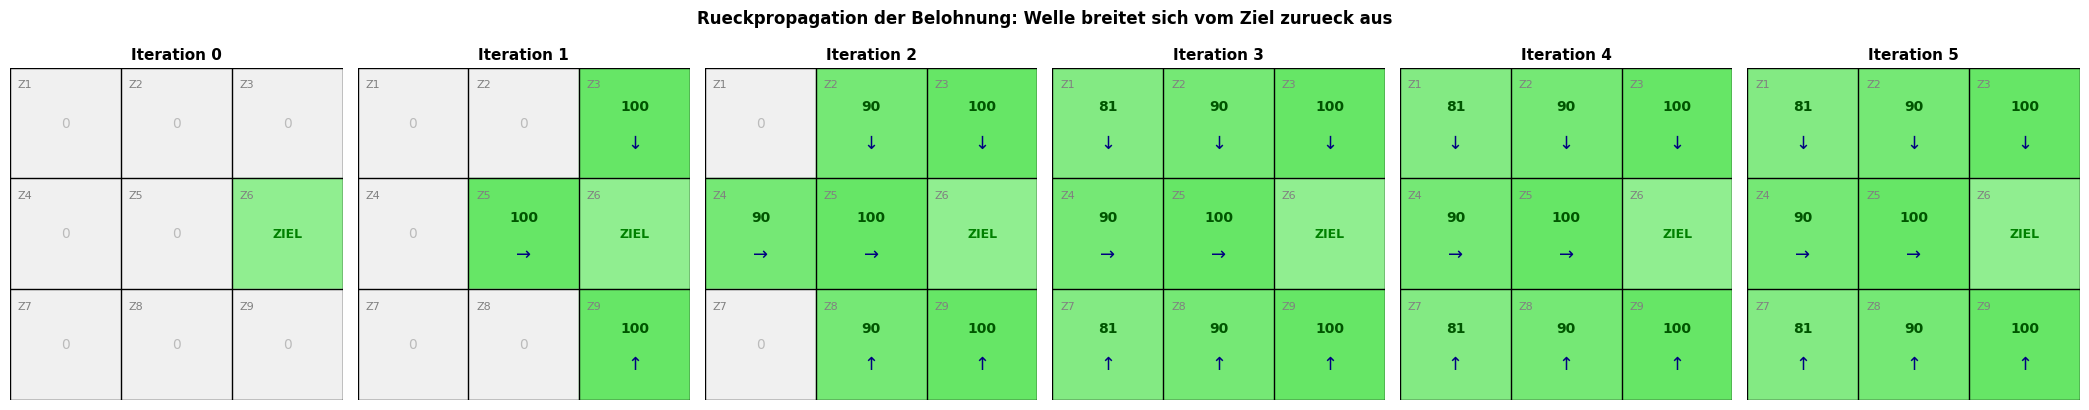

Beobachtungen:
  Iteration 0: Alle Q-Werte = 0  (Agent weiss nichts)
  Iteration 1: Z3, Z5 lernen     (direkter Zielkontakt -> Q=100)
  Iteration 2: Z2, Z4 lernen     (Nachbarn von Z3/Z5  -> Q=90)
  Iteration 3: Z1 lernt          (Nachbar von Z2      -> Q=81)
  Iteration 4+: Konvergenz (keine neuen Zustaende mehr)


In [ ]:
fig, axes = plt.subplots(1, len(q_history), figsize=(3.5 * len(q_history), 4))

for it_idx, (ax, Q_it) in enumerate(zip(axes, q_history)):
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Iteration {it_idx}', fontsize=11, fontweight='bold')

    # Gitter
    for i in range(GRID_SIZE + 1):
        ax.plot([0, GRID_SIZE], [i, i], 'k-', lw=1)
        ax.plot([i, i], [0, GRID_SIZE], 'k-', lw=1)

    max_q_it = np.max(Q_it) if np.max(Q_it) > 0 else 1

    for s in range(NUM_STATES):
        r, c   = divmod(s, GRID_SIZE)
        px     = c + 0.5
        py     = GRID_SIZE - r - 0.5
        max_s  = np.max(Q_it[s])

        # Farbe: weiss = 0, gruen = hoch
        if s == GOAL_STATE:
            color = 'lightgreen'
        elif max_s > 0:
            intensity = max_s / max_q_it
            color = (1 - intensity * 0.6, 1 - intensity * 0.1, 1 - intensity * 0.6)
        else:
            color = '#F0F0F0'

        ax.add_patch(plt.Rectangle((c, GRID_SIZE-r-1), 1, 1,
                                    color=color, zorder=0))

        # Zustandsname
        ax.text(c+0.07, GRID_SIZE-r-0.18, f'Z{s+1}',
                fontsize=8, color='gray')

        # Max-Q-Wert
        if s == GOAL_STATE:
            ax.text(px, py, 'ZIEL', fontsize=9,
                    ha='center', va='center', fontweight='bold', color='green')
        elif max_s > 0:
            ax.text(px, py+0.15, f'{max_s:.0f}',
                    ha='center', va='center', fontsize=10, fontweight='bold',
                    color='#005500')
            best_a = np.argmax(Q_it[s])
            ax.text(px, py-0.18, ARROW_CHARS[best_a],
                    ha='center', va='center', fontsize=13, color='navy')
        else:
            ax.text(px, py, '0',
                    ha='center', va='center', fontsize=10, color='#BBBBBB')

plt.suptitle('Rueckpropagation der Belohnung: Welle breitet sich vom Ziel zurueck aus',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Beobachtungen:")
print("  Iteration 0: Alle Q-Werte = 0  (Agent weiss nichts)")
print("  Iteration 1: Z3, Z5 lernen     (direkter Zielkontakt -> Q=100)")
print("  Iteration 2: Z2, Z4 lernen     (Nachbarn von Z3/Z5  -> Q=90)")
print("  Iteration 3: Z1 lernt          (Nachbar von Z2      -> Q=81)")
print("  Iteration 4+: Konvergenz (keine neuen Zustaende mehr)")

# Schritt 10: Konvergenzkurve – Wann lernt welcher Zustand?

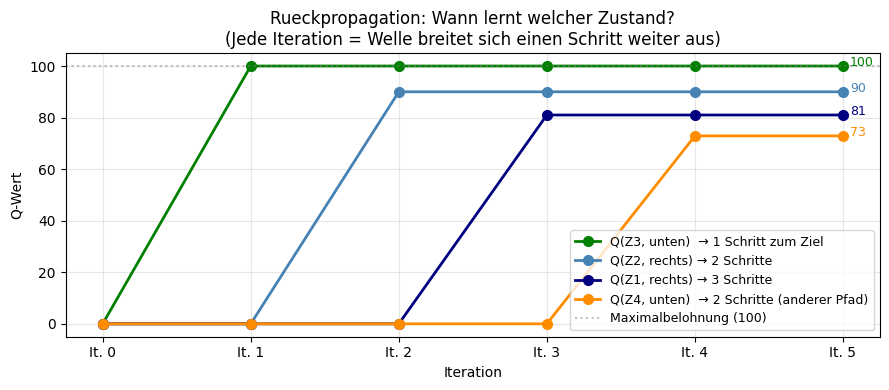

Kernbeobachtung:
  Z3 lernt in Iteration 1 (Q=100) – direkter Zielkontakt
  Z2 lernt in Iteration 2 (Q=90)  – Rueckpropagation aus Z3: 0.9 * 100
  Z1 lernt in Iteration 3 (Q=81)  – Rueckpropagation aus Z2: 0.9 * 90
  -> Die Belohnung 'wandert' rueckwaerts: Ziel belohnt Z3 belohnt Z2 belohnt Z1


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

pairs = [
    (2, 1, 'Q(Z3, unten)  → 1 Schritt zum Ziel'),
    (1, 3, 'Q(Z2, rechts) → 2 Schritte'),
    (0, 3, 'Q(Z1, rechts) → 3 Schritte'),
    (3, 1, 'Q(Z4, unten)  → 2 Schritte (anderer Pfad)'),
]
colors = ['green', 'steelblue', 'navy', 'darkorange']

for (state, action, label), col in zip(pairs, colors):
    values = [q_history[i][state, action] for i in range(len(q_history))]
    ax.plot(range(len(q_history)), values, marker='o', label=label,
            color=col, linewidth=2, markersize=7)
    # Endwert annotieren
    ax.annotate(f'{values[-1]:.0f}',
                xy=(len(q_history)-1, values[-1]),
                xytext=(5, 0), textcoords='offset points',
                fontsize=9, color=col)

ax.axhline(100, color='gray', linestyle=':', alpha=0.5, label='Maximalbelohnung (100)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Q-Wert')
ax.set_title('Rueckpropagation: Wann lernt welcher Zustand?\n'
             '(Jede Iteration = Welle breitet sich einen Schritt weiter aus)')
ax.set_xticks(range(len(q_history)))
ax.set_xticklabels([f'It. {i}' for i in range(len(q_history))])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Kernbeobachtung:")
print("  Z3 lernt in Iteration 1 (Q=100) – direkter Zielkontakt")
print("  Z2 lernt in Iteration 2 (Q=90)  – Rueckpropagation aus Z3: 0.9 * 100")
print("  Z1 lernt in Iteration 3 (Q=81)  – Rueckpropagation aus Z2: 0.9 * 90")
print("  -> Die Belohnung 'wandert' rueckwaerts: Ziel belohnt Z3 belohnt Z2 belohnt Z1")

# Schritt 11: Policy-Visualisierung – welchen Weg geht die Maus?

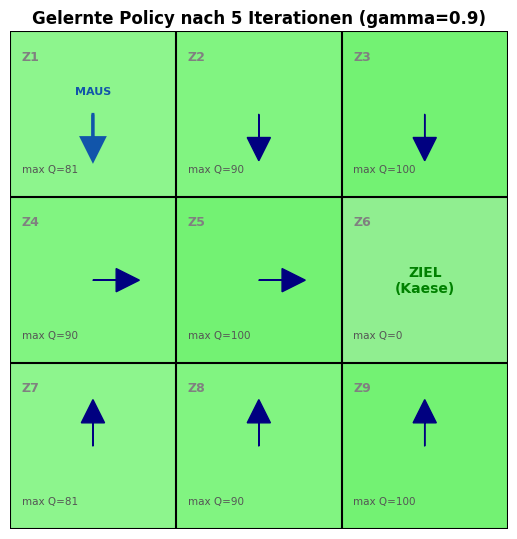

Pfeil = beste Aktion gemaess Q-Tabelle
Farbe = max. Q-Wert des Zustands (dunkler = hoeher = naeher am Ziel)

Der optimale Pfad der Maus:
  Z1 -> Z4 -> Z5 -> Z6


In [ ]:
def visualize_policy(Q, title='Gelernte Policy'):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold')

    for i in range(GRID_SIZE + 1):
        ax.plot([0, GRID_SIZE], [i, i], 'k-', lw=1.5)
        ax.plot([i, i], [0, GRID_SIZE], 'k-', lw=1.5)

    max_q = np.max(Q) if np.max(Q) > 0 else 1
    arrow_map = {0: (0, 0.28), 1: (0, -0.28), 2: (-0.28, 0), 3: (0.28, 0)}

    for s in range(NUM_STATES):
        r, c  = divmod(s, GRID_SIZE)
        px    = c + 0.5
        py    = GRID_SIZE - r - 0.5
        maxq  = np.max(Q[s])

        # Hintergrundfarbe
        if s == GOAL_STATE:
            color = 'lightgreen'
        elif maxq > 0:
            intensity = maxq / max_q
            color = (1-intensity*0.55, 1-intensity*0.05, 1-intensity*0.55)
        else:
            color = '#F5F5F5'
        ax.add_patch(plt.Rectangle((c, GRID_SIZE-r-1), 1, 1,
                                    color=color, zorder=0))

        ax.text(c+0.07, GRID_SIZE-r-0.17, f'Z{s+1}',
                fontsize=9, color='gray', fontweight='bold')
        ax.text(c+0.07, GRID_SIZE-r-0.85, f'max Q={maxq:.0f}',
                fontsize=7.5, color='#555555')

        if s == GOAL_STATE:
            ax.text(px, py, 'ZIEL\n(Kaese)', ha='center', va='center',
                    fontsize=10, fontweight='bold', color='green', zorder=3)
        elif s == START_STATE:
            best_a    = np.argmax(Q[s])
            dx, dy    = arrow_map[best_a]
            ax.arrow(px, py, dx, dy, head_width=0.14, head_length=0.14,
                     length_includes_head=True, color='#1155AA', zorder=2, linewidth=2)
            ax.text(px, py+0.14, 'MAUS', ha='center', va='center',
                    fontsize=8, color='#1155AA', fontweight='bold', zorder=3)
        else:
            best_a = np.argmax(Q[s])
            dx, dy = arrow_map[best_a]
            ax.arrow(px, py, dx, dy, head_width=0.14, head_length=0.14,
                     length_includes_head=True, color='navy', zorder=2)

    plt.tight_layout()
    plt.show()

visualize_policy(Q, f'Gelernte Policy nach {NUM_ITERATIONS} Iterationen (gamma={GAMMA})')
print("Pfeil = beste Aktion gemaess Q-Tabelle")
print("Farbe = max. Q-Wert des Zustands (dunkler = hoeher = naeher am Ziel)")
print()
print("Der optimale Pfad der Maus:")
path, s = [], START_STATE
for _ in range(10):
    path.append(f'Z{s+1}')
    if s == GOAL_STATE:
        break
    s = step(s, int(np.argmax(Q[s])))[0]
print('  ' + ' -> '.join(path))

# Schritt 12: Aufgaben

### Aufgabe 1: Gamma-Einfluss (leicht)

Verändern Sie `GAMMA` auf `0.0`, `0.5` und `1.0` und führen Sie die Value Iteration erneut aus.

- Was ändert sich an den Q-Werten?
- Was passiert bei `GAMMA = 0`? Welche Zustände lernen überhaupt?
- Was passiert bei `GAMMA = 1`? Sind alle Pfade gleich gut?

### Aufgabe 2: Gitter vergrößern (mittel)

Ändern Sie die Umgebung auf ein **4×4-Gitter** (`GRID_SIZE=4`, Käse auf Feld 16, Index 15).
- Wie viele Iterationen werden jetzt benötigt?
- Visualisieren Sie die gelernte Policy.

### Aufgabe 3: Hindernis (schwer)

Fügen Sie ein Hindernis in Z5 (Index 4) ein. Der Agent darf dieses Feld nicht betreten.
- Passen Sie `step()` an: Hindernis → Agent bleibt stehen (oder erhält Strafe).
- Findet der Agent trotzdem einen Weg zum Käse?

# Schritt 14: Ausblick – von Value Iteration zu Q-Learning

## Was haben wir gelernt?

Value Iteration funktioniert, weil wir das Modell vollständig kennen:
- Wir wissen, welche Aktionen in jedem Zustand möglich sind
- Wir wissen, welchen Folgezustand jede Aktion erzeugt
- Wir können alle Q-Werte direkt berechnen

## Was fehlt noch?

In der Praxis kennt der Agent die Umgebung **nicht vorab**.
Er muss sie durch Ausprobieren entdecken.

**Q-Learning** (nächstes Notebook K13_01) löst das:
- Der Agent bewegt sich durch das Gitter
- Nach jedem Schritt aktualisiert er **asynchron** einen Q-Wert
- Er braucht kein vollständiges Modell

**DQN** (K13_03) geht noch weiter:
- Zustandsraum ist kontinuierlich (4 reelle Zahlen bei CartPole)
- Q-Tabelle durch neuronales Netz ersetzt (4.610 Parameter statt 36 Einträge)

# Schritt 15: Merksatz

## Merksatz

**Value Iteration berechnet die optimale Policy durch wiederholte Anwendung
der Bellman-Gleichung – die Belohnung propagiert rückwärts vom Ziel zu jedem Zustand.**

Kernpunkte:

| Konzept | Bedeutung |
|---------|-----------|
| **Q-Wert Q(s,a)** | Erwarteter Gesamtreward, wenn man in Zustand s Aktion a wählt |
| **Bellman-Formel** | $Q(s,a) = b + \gamma \cdot \max_{a'} Q(s', a')$ |
| **Rückpropagation** | Belohnung breitet sich nach jeder Iteration einen Schritt weiter aus |
| **Gamma** | $\gamma=0$: nur sofortiger Reward; $\gamma=1$: alle zukünftigen Rewards gleich wichtig |
| **Value Iteration** | Synchron, braucht vollständiges Modell, skaliert nicht |
| **Q-Learning** | Asynchron, lernt durch Erfahrung, skaliert |
| **DQN** | Q-Learning + neuronales Netz für kontinuierliche Räume |